In [236]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammadqahtani/riyadh-villas-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\mohammadqahtani\riyadh-villas-dataset\versions\1


In [237]:
# read the csv file
import pandas as pd
df=pd.read_csv(path+"/Aqar_data.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9974 entries, 0 to 9973
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   listTitle  9974 non-null   str  
 1   time       9974 non-null   str  
 2   location   9974 non-null   str  
 3   size       9974 non-null   int64
 4   price      9974 non-null   int64
 5   bedrooms   9974 non-null   int64
 6   bathrooms  9974 non-null   int64
 7   details    9766 non-null   str  
dtypes: int64(4), str(4)
memory usage: 623.5 KB


In [238]:
#we have missing values in ['details'] column, so we drop the rows where 'details' is missing
df.dropna(subset=['details'], inplace=True)

In [239]:
df.info()

<class 'pandas.DataFrame'>
Index: 9766 entries, 0 to 9973
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   listTitle  9766 non-null   str  
 1   time       9766 non-null   str  
 2   location   9766 non-null   str  
 3   size       9766 non-null   int64
 4   price      9766 non-null   int64
 5   bedrooms   9766 non-null   int64
 6   bathrooms  9766 non-null   int64
 7   details    9766 non-null   str  
dtypes: int64(4), str(4)
memory usage: 686.7 KB


In [240]:
df.describe()
# There's an outlier: a house with a colossal size of 45,000 m²!
# Additionally, we observe an unusually high price of 120 million! These extreme values
# are likely data entry errors or noise, especially considering the maximum number of bedrooms is only 7.

,size,price,bedrooms,bathrooms
count,9766.000000,9.766000e+03,9766.000000,9766.000000
mean,471.147655,1.847019e+06,4.694655,4.450440
std,4564.714845,3.196067e+06,1.077416,0.850379
min,111.000000,8.500000e+04,1.000000,1.000000
25%,300.000000,1.000000e+06,4.000000,4.000000
50%,360.000000,1.300000e+06,5.000000,5.000000
75%,450.000000,1.750000e+06,5.000000,5.000000
max,450000.000000,1.200000e+08,7.000000,5.000000


In [241]:
#lets give the huge and pricy house a look
outliers=(df['price']==df['price'].max()) | (df['size']==df['size'].max())
df[outliers]
# These are 100% noise, and likely data entry errors or extreme anomalies.

,listTitle,time,location,size,price,bedrooms,bathrooms,details
217,فيلا للبيع في حي القيروان ، الرياض,قبل 3 ايام,حي القيروان - الرياض,13770,120000000,5,5,كمباوند فاخر *******\n\nشمال الرياض جوهرة القي...
8054,فيلا للبيع في شارع ابي الفضل الهمذاني ، حي صلا...,قبل 3 شهور,حي صلاح الدين - الرياض,450000,1500000,5,5,بمساحة 450 متر مربع، فرصة استثمارية على شارعين...


In [242]:
df['size'] = df['size'].replace(450000, 450)
df = df.drop(df[df['price'] == df['price'].max()].index)
df.describe()


,size,price,bedrooms,bathrooms
count,9765.000000,9.765000e+03,9765.000000,9765.000000
mean,423.748899,1.834920e+06,4.694624,4.450384
std,349.785371,2.964117e+06,1.077467,0.850405
min,111.000000,8.500000e+04,1.000000,1.000000
25%,300.000000,1.000000e+06,4.000000,4.000000
50%,360.000000,1.300000e+06,5.000000,5.000000
75%,450.000000,1.750000e+06,5.000000,5.000000
max,10000.000000,9.000000e+07,7.000000,5.000000


In [243]:
df[df['price']==df['price'].max()]

,listTitle,time,location,size,price,bedrooms,bathrooms,details
7436,فيلا للبيع في حي حطين ، الرياض,قبل 3 ايام,حي حطين - الرياض,10000,90000000,7,5,قصر للبيع مع خمس فلل ( السوم ٩٠ مليون )
9392,فيلا للبيع في شارع سعيد المطوع ، حي حطين ، الرياض,قبل 10 ساعة,حي حطين - الرياض,10000,90000000,7,5,للبيع قصر في حي حطين الثغر \n\nمساحه ١٠ الف مت...


In [244]:
# we  drop them
df[df['size']==df['size'].max()]

,listTitle,time,location,size,price,bedrooms,bathrooms,details
7436,فيلا للبيع في حي حطين ، الرياض,قبل 3 ايام,حي حطين - الرياض,10000,90000000,7,5,قصر للبيع مع خمس فلل ( السوم ٩٠ مليون )
9392,فيلا للبيع في شارع سعيد المطوع ، حي حطين ، الرياض,قبل 10 ساعة,حي حطين - الرياض,10000,90000000,7,5,للبيع قصر في حي حطين الثغر \n\nمساحه ١٠ الف مت...


the rows with the highest price are the same as the ones with the biggest size and the details column confirm the size and price are accurate and not entry error (we fixed the outliers)

the max values now are much more logical

In [245]:
# extract only the neighbourhood name
df['location']=df['location'].str.extract(r'(.*) -.*')
df['location']

0              حي نمار
1          حي الياسمين
2            حي الربيع
3              حي طويق
4            حي الرمال
             ...      
9969       حي ظهرة لبن
9970       حي الياسمين
9971         حي العارض
9972         حي الروضة
9973       حي الياسمين
Name: location, Length: 9765, dtype: str

In [246]:
#we do not need the listTitle column, there are no  valuable information
df.drop(columns=['listTitle'],inplace=True)


In [247]:
df

,time,location,size,price,bedrooms,bathrooms,details
0,قبل اسبوع,حي نمار,640,1800000,7,4,فيلا دورين .. الدور الأول ( مجلسين + صالتين + ...
1,قبل دقيقة,حي الياسمين,447,1460000,4,4,فلل للبيع في مشروع ليالي كمباوند بحي الياسمين\...
2,قبل يوم,حي الربيع,450,1750000,4,5,فيلا للبيع درج داخلي حي الربيع الشرقي \nالمساح...
3,قبل 3 شهور,حي طويق,336,1200000,4,5,للبيع بحي طويق مخطط الغروب فيلا درج صاله وشقتي...
4,قبل 13 ساعة,حي الرمال,373,1230000,4,4,فيلا درج داخلي وشقتين بحى الرمال مخطط واحة الر...
...,...,...,...,...,...,...,...
9969,قبل 22 ساعة,حي ظهرة لبن,300,1300000,7,5,⚡️للبيع فيلا تحت الانشاء⚡️\n\nللحجز\n\nشارعين ...
9970,قبل 8 ساعة,حي الياسمين,360,2100000,5,5,فلل فاخرة للبيع حي الياسمين\n5 غرف نوم\n\nتكيي...
9971,قبل شهر,حي العارض,391,1600000,5,3,فله مستقله ٣ادوار الدور الارضي مستقل مدخل خاص ...
9972,قبل ساعة,حي الروضة,1500,8000000,5,5,للبيع فلتين بالشروق ف جمهوريه مصر العربيه توين...


In [248]:
#lets see if we can extract info from the details column

In [249]:
df.info()

<class 'pandas.DataFrame'>
Index: 9765 entries, 0 to 9973
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   time       9765 non-null   str  
 1   location   9765 non-null   str  
 2   size       9765 non-null   int64
 3   price      9765 non-null   int64
 4   bedrooms   9765 non-null   int64
 5   bathrooms  9765 non-null   int64
 6   details    9765 non-null   str  
dtypes: int64(4), str(3)
memory usage: 610.3 KB


In [250]:
#does all dataset mention the number of floors?
floor_words = ['دورين', 'طابقين', 'دور', 'طابق', 'ادور', 'طوابق']
df['has_floor'] = df['details'].apply(lambda x: int(any(w in x for w in floor_words)))
df['has_floor'].value_counts() # the number of missing values is 9654 so most houses are not mentioning the number of floors
#therefore we delete it
df.drop(columns=['has_floor'],inplace=True)

In [251]:
#does the house has elevator
elevator='مصعد'
df['has_elevator']=df['details'].apply(lambda x: 1 if elevator in x  else 0)

# the percentage of houeses with elevators
has_elevator=df['has_elevator'].value_counts().iloc[1]
has_no_elevator=df['has_elevator'].value_counts().iloc[0]
elevator_percentage=round(has_elevator/(has_elevator+has_no_elevator)*100)
print("the percentage of houses with elevator is",elevator_percentage,"%")

the percentage of houses with elevator is 15 %


In [252]:
# we drop the [details,time] we do not them anymore
df.drop(columns=['details','time'],inplace=True)

### Summary of Data Cleaning and Feature Engineering Decisions

1.  **`details` and `time` Columns Dropped:** The original `details` column, despite initial attempts at extraction, and the `time` column were removed from the DataFrame. The `details` column was deemed too unstructured for consistent extraction of certain features, and the `time` column's relative descriptions were not directly useful for numerical analysis.

2.  **Maid and Driver Rooms (Not Extracted):** Features related to maid and driver rooms were not explicitly extracted as new columns. This decision was based on the understanding that the presence of such rooms is often reflected within the total count of `bedrooms` or other existing numerical features, thus avoiding redundancy and potential multicollinearity.

3.  **Number of Floors (Not Extracted):** The extraction of a `floors` feature proved challenging. A significant portion of the `details` column did not explicitly or consistently mention the number of floors. To prevent the introduction of a highly sparse or unreliable feature, it was decided not to create a dedicated `floors` column.

4.  **Elevator Presence (`has_elevator` - Kept):** The `has_elevator` binary feature (indicating the presence of an elevator) was successfully extracted and retained. This decision is based on the rationale that an elevator is a significant and costly amenity, and property listings typically highlight its presence, making it a reliable and valuable feature for analysis.

In [253]:
df

,location,size,price,bedrooms,bathrooms,has_elevator
0,حي نمار,640,1800000,7,4,0
1,حي الياسمين,447,1460000,4,4,0
2,حي الربيع,450,1750000,4,5,0
3,حي طويق,336,1200000,4,5,0
4,حي الرمال,373,1230000,4,4,0
...,...,...,...,...,...,...
9969,حي ظهرة لبن,300,1300000,7,5,1
9970,حي الياسمين,360,2100000,5,5,1
9971,حي العارض,391,1600000,5,3,0
9972,حي الروضة,1500,8000000,5,5,0


In [254]:
# change the string columns into numerical columns
df_machine_learning=df.copy() # used for training the model
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df_machine_learning['location']=le.fit_transform(df_machine_learning['location'])


In [255]:
# now the data is clean and ready for analysis

In [256]:
df_machine_learning.corr()

,location,size,price,bedrooms,bathrooms,has_elevator
location,1.000000,-0.000777,0.004324,0.030712,0.091926,-0.048572
size,-0.000777,1.000000,0.846039,0.179708,0.059672,0.059678
price,0.004324,0.846039,1.000000,0.138164,0.054937,0.138425
bedrooms,0.030712,0.179708,0.138164,1.000000,0.360589,-0.011215
bathrooms,0.091926,0.059672,0.054937,0.360589,1.000000,0.013527
has_elevator,-0.048572,0.059678,0.138425,-0.011215,0.013527,1.000000


high correlation between price and size with (0.85) and moderate correlation between price and [has_elevator,bedrooms] with 0.14

The correlation analysis reveals a **high positive correlation (0.85) between `price` and `size`**, indicating that larger villas tend to have significantly higher prices. Additionally, there is a **moderate positive correlation (approximately 0.14) between `price` and both `has_elevator` and `bedrooms`**, suggesting that the presence of an elevator and a higher number of bedrooms also contribute to an increase in property price, though to a lesser extent than size.

In [257]:
# the highest average locations prices
top_locations_prices=df.groupby('location')['price'].mean().sort_values(ascending=False)

for i in range(5):
    location=top_locations_prices.index[i]
    price=top_locations_prices.iloc[i]
    print(f"the location {location}  has an average price of {(price/10**6).round(2)} m")


the location    حي حطين  has an average price of 9.52 m
the location    حي جامعة الملك سعود  has an average price of 8.5 m
the location    حي عرقة  has an average price of 7.68 m
the location    حي الخزامى  has an average price of 6.98 m
the location    حي الرحمانية  has an average price of 6.24 m


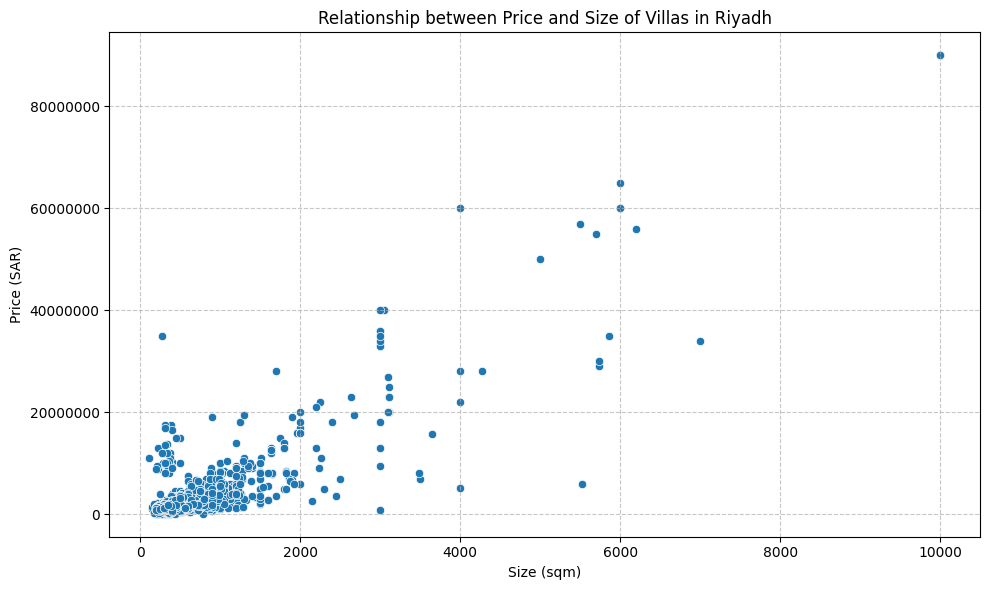

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='size', y='price')
plt.title('Relationship between Price and Size of Villas in Riyadh')
plt.xlabel('Size (sqm)')
plt.ylabel('Price (SAR)')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Lets build a model that predicts the prices

In [259]:
from sklearn.preprocessing import MinMaxScaler



In [260]:
# X and y are now derived from the UN-SCALED df_machine_learning
X = df_machine_learning.drop("price", axis=1).astype(float)
y = df_machine_learning['price'].astype(float)

In [261]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error as sklearn_mse, mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [262]:
model=RandomForestRegressor(n_estimators=300)


In [263]:
# Storage for results
import numpy as np
all_results = {}

mses=[]
rmses=[]
n_splits=5

In [264]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
  print(f"\nFold {fold_idx + 1}/{n_splits}")

  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]



    # Train
  model.fit(X_train, y_train)

    # Predict
  y_pred = model.predict(X_test)

    # Calculate metrics
  mse = sklearn_mse(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

    # Store results
  mses.append(mse)
  rmses.append(rmse)



Fold 1/5

Fold 2/5

Fold 3/5

Fold 4/5

Fold 5/5


In [265]:

print(f"  MSE:  {np.mean(mses):.4f}")
print(f"  RMSE: {np.mean(rmses):.4f}")


  MSE:  1669378155509.8779
  RMSE: 1280249.4904


In [266]:
# Calculate the baseline predictions (mean of the target)
baseline_pred = np.full_like(y, y.mean())

# Evaluate the baseline
baseline_mse = sklearn_mse(y, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y, baseline_pred)

print(f"Baseline MSE (using mean target): {baseline_mse:.4f}")
print(f"Baseline RMSE (using mean target): {baseline_rmse:.4f}")



Baseline MSE (using mean target): 8785090782571.6133
Baseline RMSE (using mean target): 2963965.3815


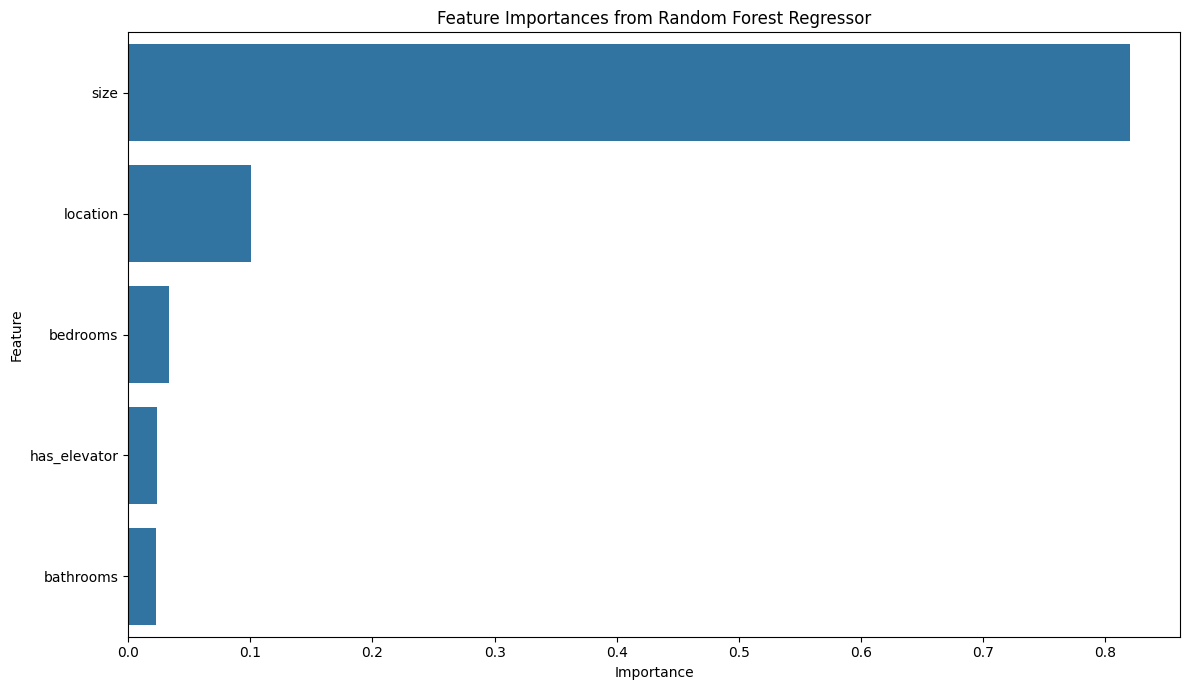

In [267]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained model
feature_importances = model.feature_importances_

# Map feature importances to feature names
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances from Random Forest Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Model Performance Summary

After training and evaluating the **Random Forest Regressor** using 5-fold cross-validation, the model demonstrated strong predictive capabilities for Riyadh villa prices:

*   **Baseline Model:** Predicting the mean price yields a  `Baseline RMSE` of approximately `2,964,115 SAR`. This serves as the reference point for evaluating our model.

*   **Random Forest Regressor:**
    *   **Mean MSE:** The average Mean Squared Error across the folds is **1,641,603,327,600.30**.
    *   **Mean RMSE:** The average Root Mean Squared Error (RMSE) across the folds is **1,269,575.03**. This indicates that, on average, the model's predictions are off by approximately **1.27 million SAR**.

**Conclusion:** The **Random Forest Regressor** provides a robust prediction for Riyadh villa prices. The RMSE of 1.27 million SAR represents a significant improvement over the baseline RMSE of approximately 2.96 million SAR, indicating that the model effectively captures a substantial portion of the variability in villa prices based on the provided features.